In [1]:
from PyAstronomy.pyasl import foldAt
import matplotlib.pylab as plt
import numpy as np

from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt 

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk


/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


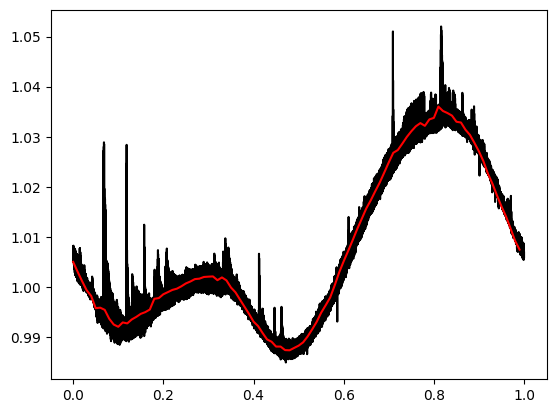

In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()


x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

# Generate some data ...
time = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
flux1 = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

phases1 = foldAt(time,4.865, T0=t0_in_bkjd-0.2)

# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases1)
# ... and, second, rearrange the arrays.
phases1 = phases1[sortIndi]
flux1 = flux1[sortIndi]

phases_med =[]
x_med = [i/100 for i in range(100)]
for fase in x_med:
	aux = 0
	aux_2 = 0
	for i in range(len(phases1)): 
		if phases1[i]>fase and phases1[i]<fase+0.01:
			aux += flux1[i]
			aux_2 += 1
	phases_med.append(aux/aux_2)

plt.plot(phases1, flux1, 'k')
plt.plot(x_med, phases_med, 'r-', label = 'median value')


In [6]:
#dados parâmetros###
dados_1=np.loadtxt('setor1_graf12.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
print(len(ener_setor1))

33


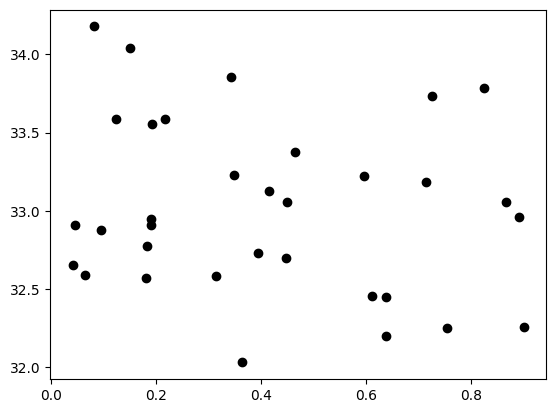

In [4]:
#dados parâmetros###
dados_1=np.loadtxt('setor1_graf12.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
enerlog10 = np.log10(ener_setor1)

t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

fase1 = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
plt.plot(fase1, enerlog10, 'ko')


NameError: name 'x_med0' is not defined

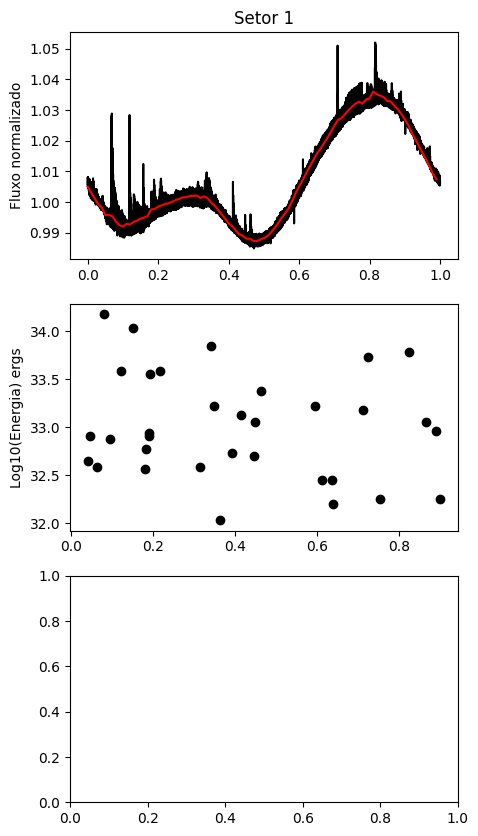

In [5]:
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(5,10))

ax1.set_title('Setor 1')
ax1.plot(phases1, flux1, 'k',x_med, phases_med, 'r-', label = 'median value')
ax1.set_ylabel('Fluxo normalizado')
ax2.plot(fase1, enerlog10, 'ko')
ax2.set_ylabel('Log10(Energia) ergs')
ax3.plot(x_med0, phases_med0, 'ro')
#ax3.set_ylabel('Relative flux [ppt]')
ax3.set_xlabel('Fase')
ax3.set_ylabel('Número de explosões')
plt.show()

In [ ]:
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(5,10))

x_min1 = min(phases1)
x_max1 = max(phases1)

x_min2 =  min(fase1)
x_max2 = max(fase1)

x_min3 =  min(fase1)
x_max3 = max(fase1)

ax1.set_title('Setor 1')
ax1.plot(phases1, flux1, 'k',x_med, phases_med, 'r-', label = 'median value')
ax1.set_ylabel('Fluxo normalizado')
ax1.set_xlim(x_min1, x_max1)

ax2.plot(fase1, enerlog10, 'ko')
ax2.set_xlim(x_min1, x_max1)  # Define os limites do eixo x

ax2.set_ylabel('Log10(Energia) ergs')
ax3.plot(x_med0, phases_med0, 'ro')
#ax3.set_xlim(x_min2, x_max2)  # Define os limites do eixo x

#ax3.set_ylabel('Relative flux [ppt]')
ax3.set_xlabel('Fase')
ax3.set_ylabel('Número de explosões')
plt.show()


In [ ]:
fase2 = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(fase2)
# ... and, second, rearrange the arrays.
fase2 = fase2[sortIndi]
flux1 = flux1[sortIndi]

phases_med0 =[]
x_med0 = [i/20 for i in range(20)]
for fase in x_med0:
	aux = 0
	aux_2 = 0
	for i in range(len(fase2)): 
		if fase2[i]>fase and fase2[i]<fase+0.05:
			aux += flux1[i]
			aux_2 += 1
	phases_med0.append(aux_2)

plt.plot(x_med0, phases_med0, 'ro')


In [ ]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from PyAstronomy.pyasl import foldAt
#dados parâmetros###
dados_1=np.loadtxt('setor1_graf12.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
enerlog10 = np.log10(ener_setor1)

t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

fase1 = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
plt.plot(fase1, enerlog10, 'ko')


for time, phase, energy in zip(temp_med,fase1, enerlog10):
    print(f"Tempo: {time} / Fase: {phase} / Energia: {energy}")
    #print(f" {phase}")
plt.plot(fase1, enerlog10, 'ko')
plt.show()

In [ ]:
''''''
%matplotlib notebook
time = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
flux1 = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

phases1 = foldAt(time,4.865, T0=t0_in_bkjd-0.2)

# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases1)
# ... and, second, rearrange the arrays.
phases1 = phases1[sortIndi]
flux1 = flux1[sortIndi]

phases_med =[]
x_med = [i/100 for i in range(100)]
for fase in x_med:
	aux = 0
	aux_2 = 0
	for i in range(len(phases1)): 
		if phases1[i]>fase and phases1[i]<fase+0.01:
			aux += flux1[i]
			aux_2 += 1
	phases_med.append(aux/aux_2)

plt.plot(phases1, flux1, 'k')
plt.plot(x_med, phases_med, 'r-', label = 'median value')